**Relevant reading for this problem set**:
<a href="https://moderndive.com/10-inference-for-regression.html"
target="_blank">ModernDive Chapter 10: Inference for Regression</a>.

## Background

For this problem set you will apply statistical inference to a linear
modeling and explore methods to check the required conditions. To start
we will build a model using data from the `palmerpenguins` package. The
`penguins` data contains size measurements for three penguin species
observed on three islands in the Palmer Archipelago, Antarctica.

First we will start with our typical exploratory data analysis and then
build our linear model. From there we will use our new skills to make
inferences about our regression model and check the necessary
conditions.

### Load packages

We will read the data in from the`palmerpenguins` package, explore the
data using the `dplyr` package and visualize it using the `ggplot2`
package. The `moderndive` package includes some nice functions to show
regression model outputs and finally use the `infer` package for “tidy”
and transparent statistical inference.

In [1]:
install.packages("moderndive")
#install.packages("dplyr")
install.packages("palmerpenguins")

library('moderndive')
library('infer')
library('palmerpenguins')
library('tidymodels')

also installing the dependencies ‘snakecase’, ‘operator.tools’, ‘janitor’, ‘formula.tools’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw


── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.11     ✔ rsample      1.3.1 
✔ dials        1.4.2      ✔ tailor       0.1.0 
✔ dplyr        1.1.4      ✔ tidyr        1.3.2 
✔ ggplot2      4.0.1      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.4.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.0      ✔ yardstick    1.3.2 
✔ recipes      1.3.1      

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr

### The data

In [3]:
pen = penguins |> 
  filter(!is.na(flipper_length_mm))


In [4]:
glimpse(pen)

Rows: 342
Columns: 7
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adel…
$ island            <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torgerse…
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, 36.7, 39.3, 38.9, 39.2, 34.1, 42.0…
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, 19.3, 20.6, 17.8, 19.6, 18.1, 20.2…
$ flipper_length_mm <int> 181, 186, 195, 193, 190, 181, 195, 193, 190, 186, 18…
$ body_mass_g       <int> 3750, 3800, 3250, 3450, 3650, 3625, 4675, 3475, 4250…
$ sex               <fct> male, female, female, female, male, female, male, NA…


In [5]:
head(pen)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>
Adelie,Torgersen,39.1,18.7,181,3750,male
Adelie,Torgersen,39.5,17.4,186,3800,female
Adelie,Torgersen,40.3,18.0,195,3250,female
Adelie,Torgersen,36.7,19.3,193,3450,female
Adelie,Torgersen,39.3,20.6,190,3650,male
Adelie,Torgersen,38.9,17.8,181,3625,female


Take a moment to look at the data using `glimpse` and `head`. The dataset contains 8
variables. You can read more about the variables by placing your cursor in `penguins` and 
looking at the `Contextual Help` tool.

For our lab we will focus on four variables, the explanatory variables
include:

-   `flipper_length_mm` - an integer denoting flipper length
    (millimeters)
-   `bill_length_mm` - a number denoting bill length (millimeters)
-   `species`- denotes penguin species (Adélie, Chinstrap and Gentoo)

The outcome variable `body_mass_g` is an integer denoting body mass
(grams).

### Visualization

We will start by investigating the relationship between
‘flipper_length_mm’ and ‘body_mass_g’.

`geom_smooth()` using formula = 'y ~ x'


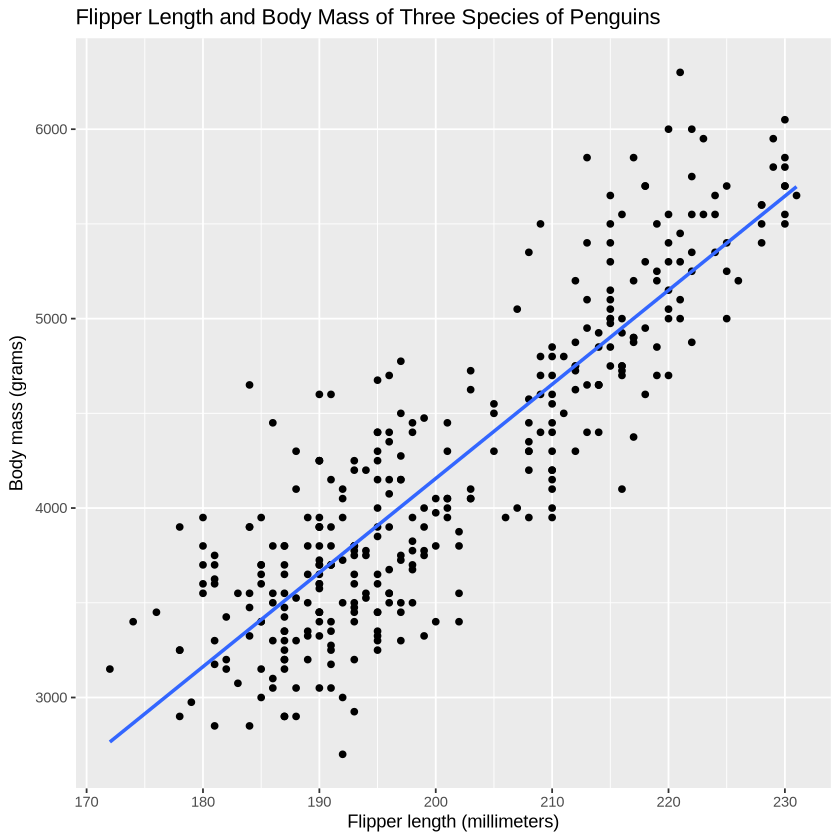

In [6]:
ggplot(data = pen, aes(y = body_mass_g, x = flipper_length_mm)) + 
  geom_point() + 
  geom_smooth(method = "lm", se = FALSE) +
  labs(x = "Flipper length (millimeters)", 
       y = "Body mass (grams)", 
       title = "Flipper Length and Body Mass of Three Species of Penguins") 

## Question 1

Does the relationship appear to be positive or negative? Does it look to
be reasonably linear?

## **Answer:**  According to the plot above, the relationship between Body mass and Flipper length is a positive relationship that appears to be linear.  

## Create a linear regression model

Here we use the [standard error](https://moderndive.com/10-inference-for-regression.html#regression-se) to calculate a confidence interval. Later we will use the bootstrap resampling technique
that does not rely on distrubutional assumptions.

In [7]:
mod = linear_reg() |> set_engine('lm')

pen_model = mod |> fit(body_mass_g ~ flipper_length_mm, data = pen)

tidy(pen_model) |> mutate(lower_ci = estimate - 1.96 * std.error, upper_ci = estimate + 1.96 * std.error)

term,estimate,std.error,statistic,p.value,lower_ci,upper_ci
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-5780.83136,305.814504,-18.90306,5.587301e-55,-6380.22779,-5181.43493
flipper_length_mm,49.68557,1.518404,32.72223,4.370681e-107,46.70949,52.66164


## Question 2

Using our shorthand interpretation for confidence intervals and the
regression table, write a sentence interpreting the 95% confidence
interval for $\beta_1$?

**Answer:**

## For this sample, the estimate slope of the line (which is 49.69 g/mm), or ˆβ1 falls between the lower (46.709) and upper (52.661) confidence intervals calculated.  If we repeated this investigation on similar penguins and constructed additional confidence intervals using the same method, then about 95% of those intervals would contain the true slope.  


## Question 3

Recall that the test statistic and $p$-value correspond to the
hypothesis test:

$$\begin{aligned} H_0:&\beta_{1} = 0 \\\ \mbox{vs }H_A:& \beta_{1} \neq 0 \end{aligned}$$

Write up the results & conclusions for this hypothesis test.

**Answer:**

## Looking at the information given in the linear regression model above, we know that we're using a 95% confidence interval, so alpha = 0.05.  The p-value is the probability of obtaining a test statistic just as extreme or even more extreme than the observed test statistic assuming the null hypothesis is true.  In this case the test statistic is t = 32.72223 and the p-value is 4.37e-107 which is << 0.05 and essentially p = 0.  (In these cases it's common to say p < 0.001.).  Regardless, p < 0.05 which tells us we must reject our null hypothesis that the population slope equals zero and we can conclude that longer flippers are associated with a greater body mass.  



## Question 4

You may remember that this hypothesis test is only valid if certain
“conditions for inference for regression” are met. Let’s take a closer
look those conditions.

1.  Linearity of relationship between variables
2.  Independence of the residuals
3.  Normality of the residuals
4.  Equality of variance of the residuals

## Linearity of relationship between variables

**4a) ** This was analyzed in question 1. Did you say that the
relationship between `flipper_length_mm` and `body_mass_g` appears to be
linear?

**Answer:**

## Yes, I said the relationship between flipper_length_mm and body_mass_g appears to be linear and positive.  



## Independence of the residuals

The observations in our data must be independent of one another. In this
data, we can not be sure this is case, for example, some of the penguins
included may be related (siblings, parents). We are not given enough
information to verify this condition has been met.

## Normality of the residuals

The third condition is that the residuals should follow a Normal
distribution centered 0. To check for normality, create a histogram.

The code to get the residuals is given.

In [8]:
regression_points = augment(pen_model, new_data = pen)

regression_points |> head()

.pred,.resid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>
3212.256,537.743839,Adelie,Torgersen,39.1,18.7,181,3750,male
3460.684,339.316007,Adelie,Torgersen,39.5,17.4,186,3800,female
3907.854,-657.854091,Adelie,Torgersen,40.3,18.0,195,3250,female
3808.483,-358.482958,Adelie,Torgersen,36.7,19.3,193,3450,female
3659.426,-9.426259,Adelie,Torgersen,39.3,20.6,190,3650,male
3212.256,412.743839,Adelie,Torgersen,38.9,17.8,181,3625,female


**4b)**

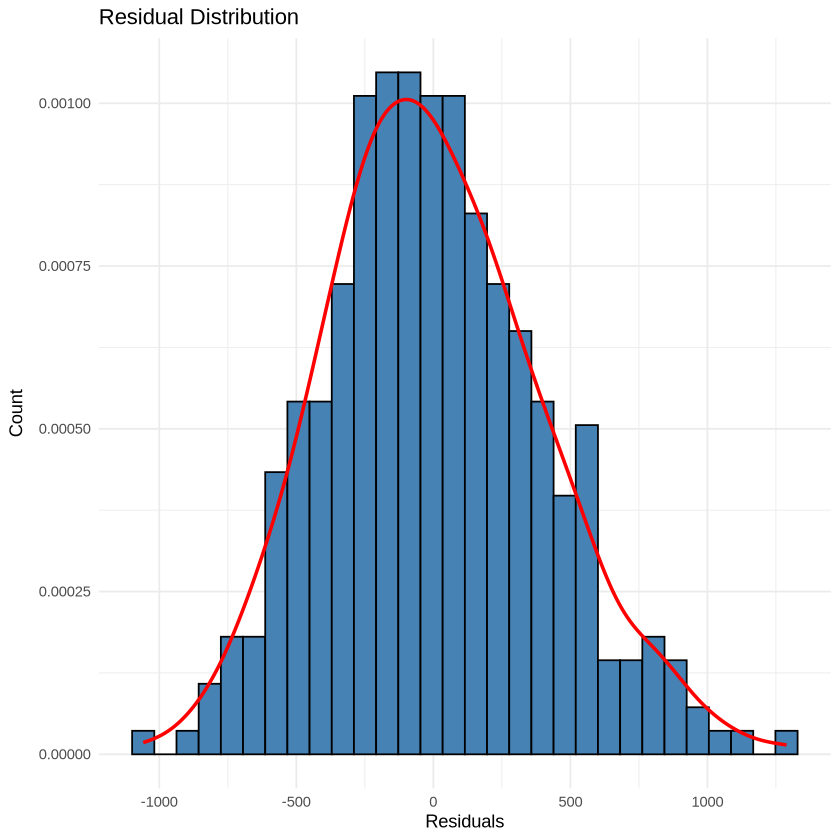

In [9]:
#Add code for the histogram.
ggplot(regression_points, aes(x = .resid)) +
    geom_histogram(aes(y = after_stat(density)),
        bins = 30, 
        fill = "steelblue", 
        color = "black") +
    geom_density(color = "red", linewidth = 1) +
    labs(
        title = "Residual Distribution", 
        x = "Residuals",
        y = "Count"
    ) +
    theme_minimal()



**4c)** Does this model meet the normality of residuals condition?

**Answer:**

## According to the plot of the residual distribution of the body mass appears to follow a normal distribution centered about 0.  So yes, the model meets the normality of the residuals condition.  



## Equality of variance of the residuals

The final condition says that the residual should exhibit equal variace
across all of the values of the explanatory variable.

To check this condition we can create a scatterplot that has our
explanatory variable, `flipper_length_mm`, on the x-axis and our
residuals on the y-axis. Does this model meet the Normality of Residuals
condition?

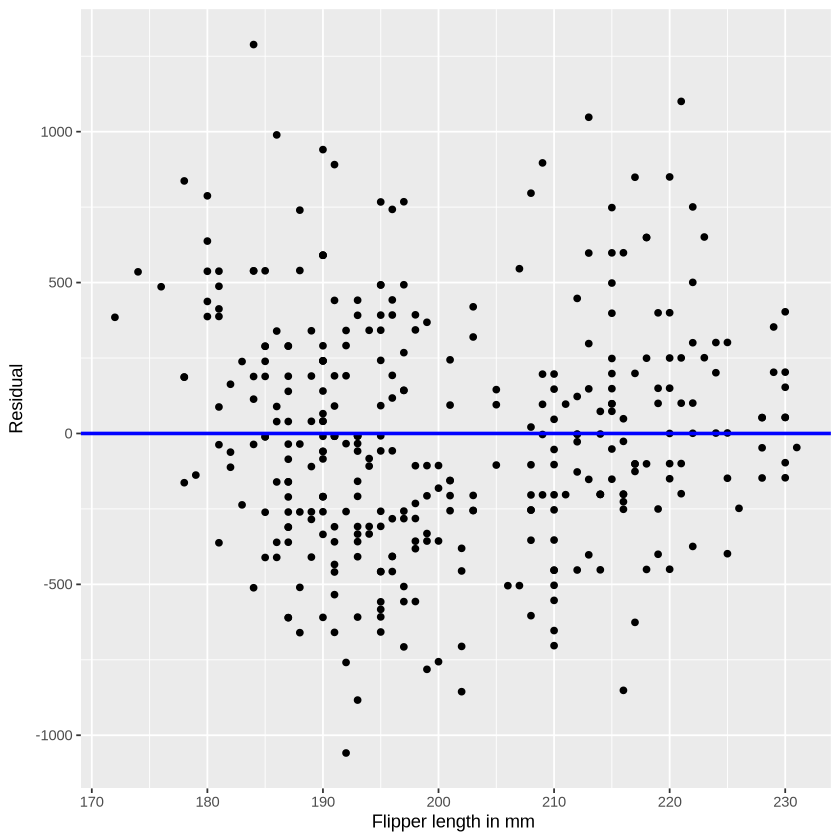

In [10]:
ggplot(regression_points, aes(x = flipper_length_mm, y = .resid)) +
  geom_point() +
  labs(x = "Flipper length in mm ", y = "Residual") +
  geom_hline(yintercept = 0, col = "blue", linewidth = 1)

**4d.** Does this model meet the equality of variance condition?

**Answer:**

## Yes, the plot of the residuals of the flipper_length_mm appears to be appears to be show a reasonably constant distribution around the line y =0 across the explanatory variable flipper_length_mm.  



## Question 5

Now let’s circle back and take a second look at the confidence
intervals. Using this bootstrap distribution, we’ll construct the 95%
confidence interval using the percentile method and (if appropriate) the
standard error method as well. We can compare our results to the results
from R (which uses mathematical formula to construct confidence
intervals.)

### Step 1: Calculate the bootstrap statistic and Visualize the bootstrap distribution

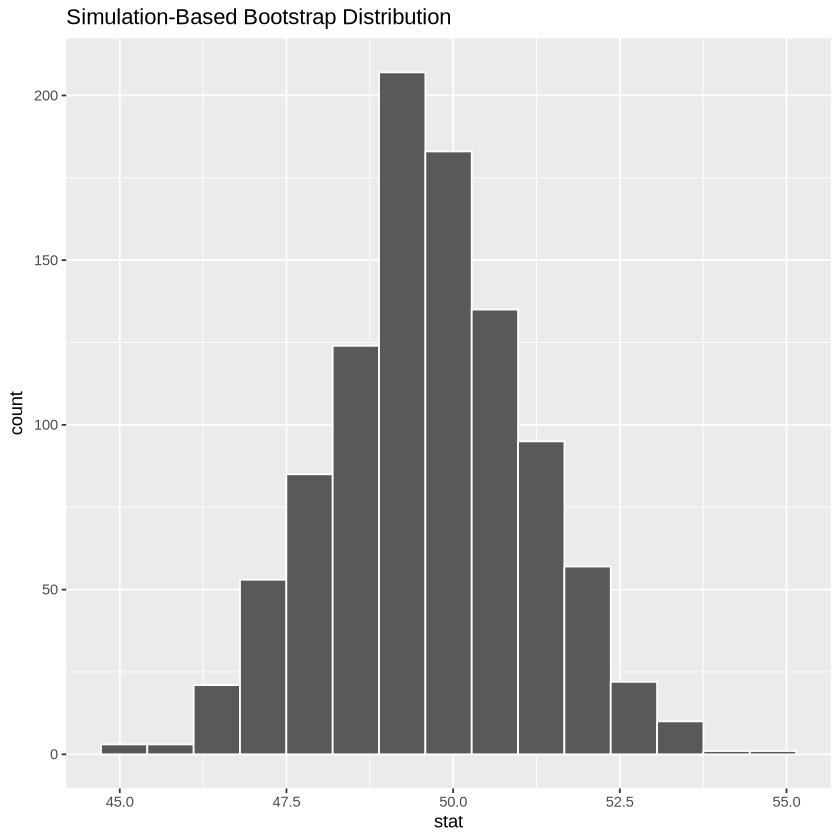

In [12]:
bootstrap_distn_slope = pen |> 
  specify(formula = body_mass_g ~ flipper_length_mm) |>
  generate(reps = 1000, type = "bootstrap") |>
  calculate(stat = "slope")

visualize(bootstrap_distn_slope)

### Step 2: Calculate CI from the a bootstap resample using the percentile method.

Find a 95% CI using percentile method:

In [13]:
#finish the code here:
#  this uses the percentile method
bootstrap_distn_slope |>
    summarize(lower_ci = quantile(stat, 0.025), upper_ci = quantile(stat, 0.975))


lower_ci,upper_ci
<dbl>,<dbl>
46.79404,52.697


In [14]:
# this method will calculate the 95% CI using the standard error

bootstrap_se <- bootstrap_distn_slope |>
    summarize(se = sd(stat)) |>
    pull(se)

orig_slope <- pen |>
    specify(body_mass_g ~ flipper_length_mm) |>
    calculate(stat = "slope") |>
    pull()

lower_ci <- orig_slope - 1.96*bootstrap_se
upper_ci <- orig_slope + 1.96*bootstrap_se

c(lower_ci, upper_ci)

flipper_length_mm flipper_length_mm 
         46.76659          52.60455

## Question 6

Write down the two 95% confidence intervals for the $\beta_{1}$. a, b,
c, and d with the appropriate values you’ve computed.

When you are done, make sure all the `|` in the table still line up so
your results print out in a table!

| CI construction method                | lower value | upper value |
|---------------------------------------|-------------|-------------|
| Using bootstrap: percentile rule      | 46.8979     | 52.52337    |
| Using bootstrap: standard error       | 46.8310     | 52.54006    |
| Using mathematical formula            | 46.70949    | 52.66164    |

In your opinion, would you say these three confidence intervals are
similar?

## **Answers:** Yes, these three confidence intervals are very similar and show consistency between the methods of calculating the CI. 

## Part 2

For the next part you will check the conditions for regression inference
for a new model. This model will have `bill_length_mm` and `species` as
explanatory variables, and we’ll use the parallel slopes model

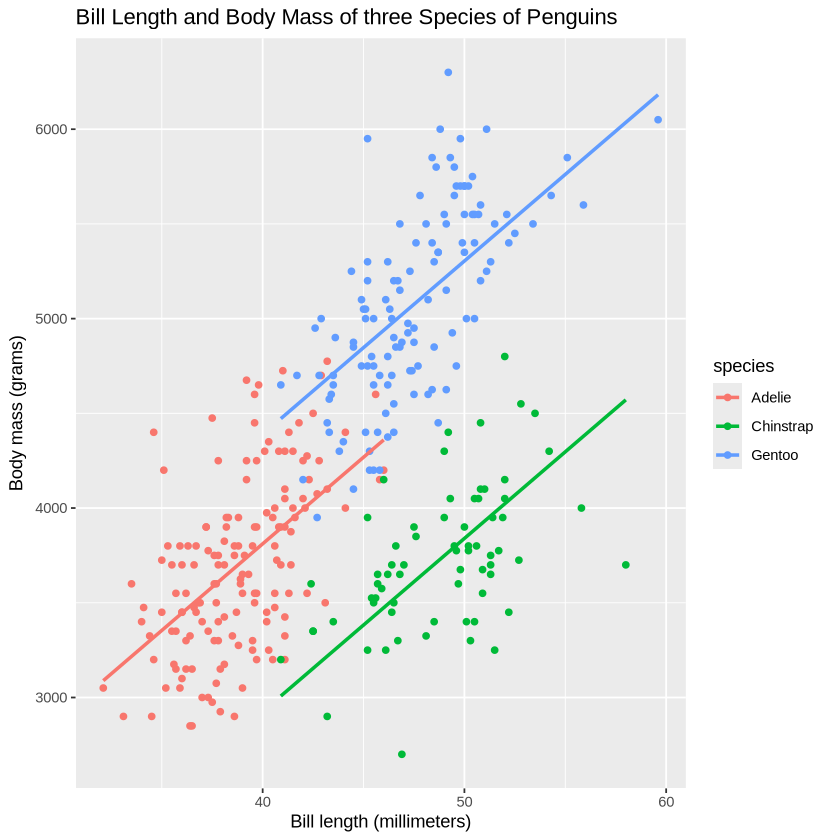

In [15]:
ggplot(data = pen, aes(y = body_mass_g, x = bill_length_mm, color=species)) + 
  geom_point() + 
  geom_parallel_slopes(se = FALSE) +
  labs(x = "Bill length (millimeters)", 
       y = "Body mass (grams)", 
       title = "Bill Length and Body Mass of three Species of Penguins") 

Let’s fit the parallel slopes model

In [16]:
# Fit regression model:

mod = linear_reg() |> set_engine('lm')

pen_parallel = mod |> fit(body_mass_g ~ bill_length_mm + species, data = pen)

# Get regression table:
tidy(pen_parallel)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),153.73969,268.901233,0.5717329,5.678829e-01
bill_length_mm,91.43582,6.887119,13.2763517,1.158990e-32
speciesChinstrap,-885.81208,88.250154,-10.0375131,6.373927e-21
speciesGentoo,578.62916,75.362341,7.6779617,1.756354e-13


Let us once again inspect the conditions necessary for inference with
regression.

1.  Linearity of relationship between variables
2.  Independence of the residuals
3.  Normality of the residuals
4.  Equality of variance of the residuals

## Question 7

**Check for Linearity of relationship between variables **

Would you say that the relationship between `bill_length_mm` and
`body_mass_g` appears to be linear for each species?

**Answer:**

## Yes, according to the plots of the data of the three species of penguins above, the relationships between the bill_length__ vs body_mass_g appear to be linear for each species.  



**Check for Independence of the residuals **

This is the same as the first model that we looked it. The observations
in our data must be independent of one another. In this data, we can not
be sure this is case, for example, some of the penguins included may be
related (siblings, parents). We are not given enough information to
verify this condition has been met.

## Question 8

Check Normality of the residuals (and they should be centered at 0.)

**8a) **

In [17]:
#Add code for the histogram:
regression_points_parallel = augment(pen_parallel, new_data = pen)

regression_points_parallel |> head()


.pred,.resid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>
3728.880,21.11981,Adelie,Torgersen,39.1,18.7,181,3750,male
3765.455,34.54548,Adelie,Torgersen,39.5,17.4,186,3800,female
3838.603,-588.60318,Adelie,Torgersen,40.3,18.0,195,3250,female
3509.434,-59.43423,Adelie,Torgersen,36.7,19.3,193,3450,female
3747.167,-97.16736,Adelie,Torgersen,39.3,20.6,190,3650,male
3710.593,-85.59303,Adelie,Torgersen,38.9,17.8,181,3625,female


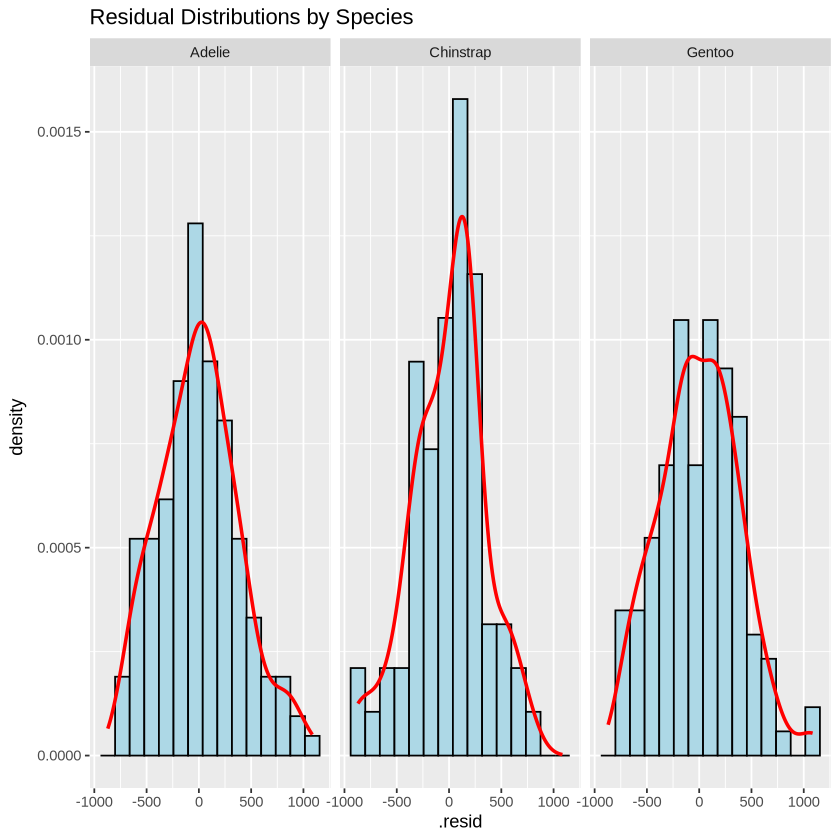

In [18]:
ggplot(regression_points_parallel, aes(x = .resid)) +
  geom_histogram(
                 aes(y = after_stat(density)),  # this scales the histogram to the density units so that the red curve aligns correctly with the bars
                 bins = 15,
                 color = "black",
                 fill = "lightblue") +
  geom_density(color = "red", linewidth = 1) +
  facet_wrap(~ species) +
  labs(title = "Residual Distributions by Species")

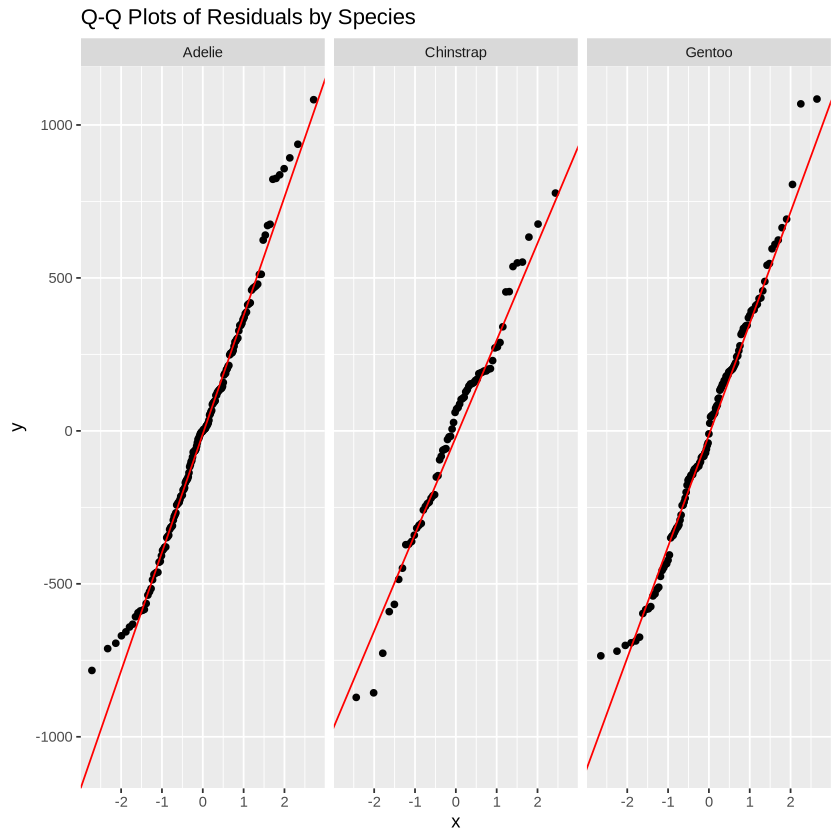

In [19]:
## this makes Q-Q plots which I remembered from a previous stat course...

ggplot(regression_points_parallel, aes(sample = .resid)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  facet_wrap(~ species) +
  labs(title = "Q-Q Plots of Residuals by Species")

**8b)** Does this model meet the Normality of Residuals condition?

**Answer:**

## The histograms of the residuals of each species are plotted above and appear to be normally distributed about x = 0.  I remembered from a previous stat-class the Q-Q plot, which can be used to determine normality, and I created Q-Q plots for each species.  As long as the distribution falls along the red line the residuals are normally distributed.  The Q-Q plots below show that each species' residuals are normally distributed and back up the observations of the histograms above.  

## Question 9

Check for Equality of variance of the residuals

To check this condition we can create a scatterplot that has our
explanatory variable, `flipper_length_mm`, on the x-axis and our
residuals on the y-axis.

**9a)**

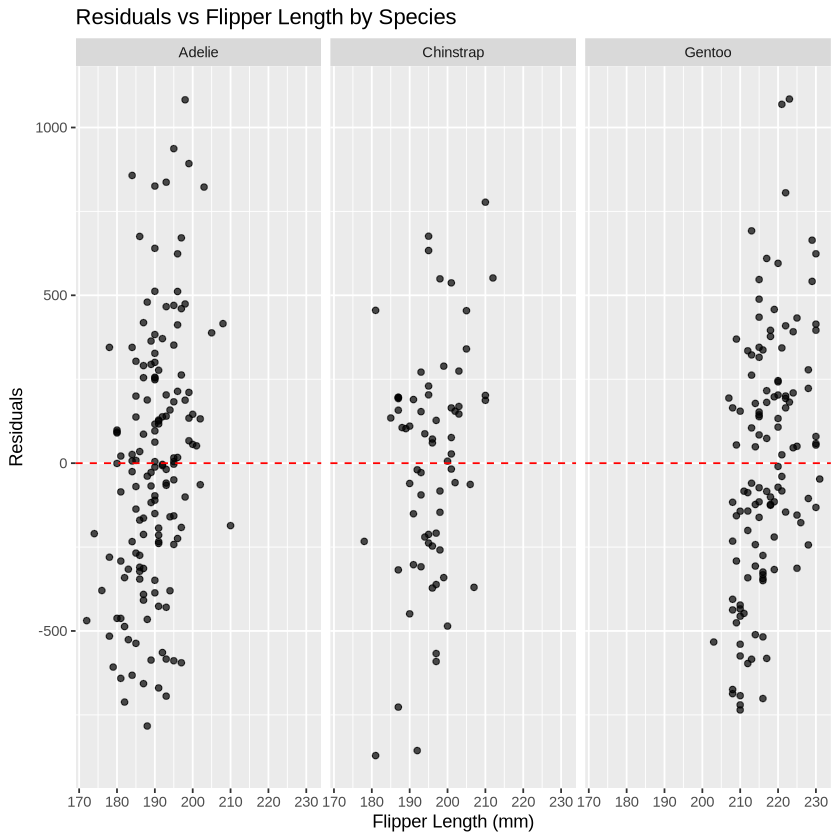

In [20]:
#Add code to check this condition:
ggplot(regression_points_parallel, aes(x = flipper_length_mm, y = .resid)) + 
    geom_point(alpha = 0.7) +
    geom_hline(yintercept = 0,
               color = "red",
               linetype = "dashed") +
    facet_wrap(~species) +
    labs(
        x = "Flipper Length (mm)",
        y = "Residuals", 
        title = "Residuals vs Flipper Length by Species"
    )


**9b) **Does this meet the equality of variance of the residuals
condition?

**Answer:**

## The residuals for each species are spread about the y = 0 line appear to be constant across flipper length.  Although one could argue that the Chinstrap distribution might be more skewed toward the negative residual range, but not enough to say that the condition is not met.  Based on these plots, I would conclude that the condition of equality of variance of the residuals is met.  



## Question 10

Run the code below to find the confidence intervals for our model's coefficients.

In [21]:
boots = bootstraps(pen, times = 1000, apparent = TRUE)

mod = linear_reg() |> set_engine('lm')

boot_models  = boots |> 
  mutate(model = map(splits, ~mod |> fit(body_mass_g ~ bill_length_mm + species, data = as_tibble(.x))),
         coef_info = map(model, tidy))

boot_coefs = boot_models |> 
  unnest(coef_info)

percentile_intervals = int_pctl(boot_models, coef_info)

percentile_intervals

term,.lower,.estimate,.upper,.alpha,.method
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
(Intercept),-351.19061,154.19299,635.3896,0.05,percentile
bill_length_mm,79.41163,91.41538,104.2668,0.05,percentile
speciesChinstrap,-1026.44240,-885.47542,-740.7358,0.05,percentile
speciesGentoo,435.02313,579.51223,720.7678,0.05,percentile


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


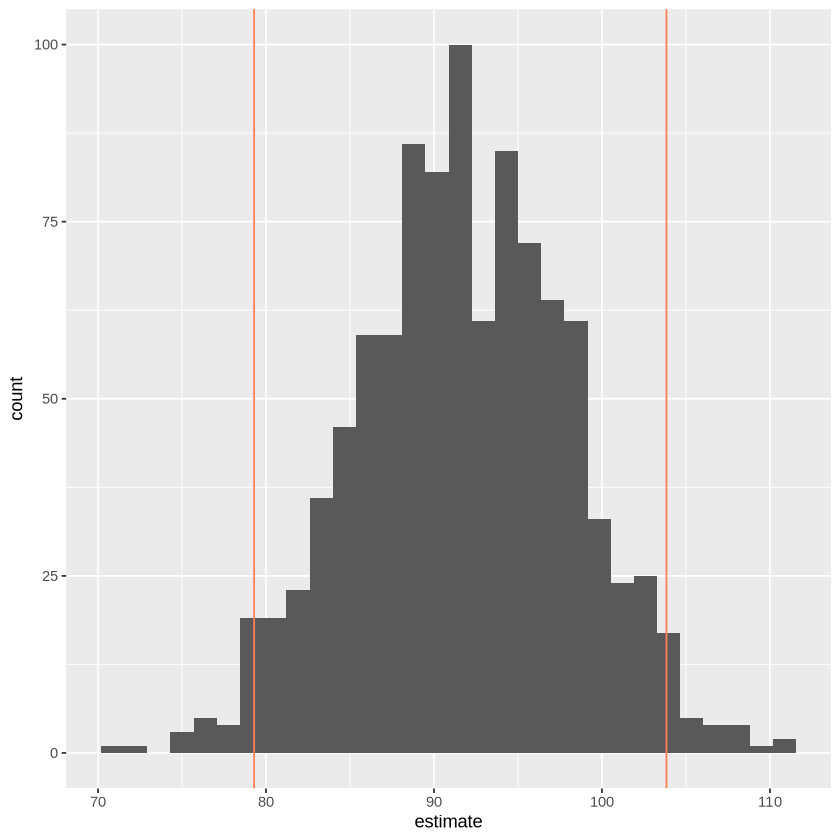

In [24]:
boot_coefs |> 
    filter(term == 'bill_length_mm') |>
ggplot(aes(x = estimate)) +
    geom_histogram() +
    geom_vline(xintercept = percentile_intervals |> filter(term == 'bill_length_mm') |> pull(.lower), color = 'coral') +
    geom_vline(xintercept = percentile_intervals |> filter(term == 'bill_length_mm') |> pull(.upper), color = 'coral')

What can we conclude about the relationship between bill length and body
mass?

**Answer:**

## We can conclude that the parallel slopes model gives the equation:
## body_mass_g = 140.79 + 91.75*(bill_length_mm) - 888.90*(Chinstrap) + 575.46*(Gentoo)
## The equation is designed to be used for all three species.  If the penguin is a Chinstrap = 1, otherwise = 0.  Use Gentoo = 1 if the penguin is a Gentoo, or 0 otherwise.  Adelie is the reference species and to get information on the Adelie penguins, then the Gentoo and Chinstrap indicators both = 0.  
## All three species gain body mass as their bill length increases (by 91.75 g/mm) but each species differs in their initial baseline body mass as given by the y-intercepts.

